## **02. Sequential Models (LSTM / BiLSTM) - PyTorch**

**Objective**: Build sequential deep learning models that capture word order and context for improved spam detection.

**Models**:
1. Simple LSTM
2. Bidirectional LSTM (BiLSTM)
3. Conv1D + BiLSTM (hybrid)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings
warnings.filterwarnings('ignore')
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__} | Device: {device}")

spam_data_path = '../data/spam.csv'
outputs_model_path = '../outputs/models'

PyTorch: 2.12.0+cu130 | Device: cpu


### **1. Data Loading, Preprocessing & Tokenization**

In [4]:
# Load and prepare data
df = pd.read_csv(spam_data_path, encoding='latin-1')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
df['label_encoded'] = (df['label'] == 'spam').astype(int)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' url ', text)
    text = re.sub(r'\d+', ' num ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)

# Split
X = df['text_clean'].values
y = df['label_encoded'].values
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 3900 | Val: 836 | Test: 836


In [5]:
# Vocabulary & encoding
MAX_VOCAB_SIZE = 10000
MAX_SEQ_LENGTH = 150
EMBEDDING_DIM = 128
BATCH_SIZE = 32

class Vocabulary:
    def __init__(self, max_size=10000):
        self.word2idx = {'<PAD>': 0, '<OOV>': 1}
        self.max_size = max_size

    def build(self, texts):
        word_counts = Counter()
        for text in texts:
            word_counts.update(text.split())
        for word, _ in word_counts.most_common(self.max_size - 2):
            self.word2idx[word] = len(self.word2idx)
        return self

    def encode(self, text, max_length):
        tokens = text.split()[:max_length]
        ids = [self.word2idx.get(w, 1) for w in tokens]
        ids += [0] * (max_length - len(ids))
        return ids

    def __len__(self):
        return len(self.word2idx)

vocab = Vocabulary(MAX_VOCAB_SIZE).build(X_train)
X_train_enc = np.array([vocab.encode(t, MAX_SEQ_LENGTH) for t in X_train])
X_val_enc = np.array([vocab.encode(t, MAX_SEQ_LENGTH) for t in X_val])
X_test_enc = np.array([vocab.encode(t, MAX_SEQ_LENGTH) for t in X_test])

In [6]:

# Dataset & Loaders
class SpamDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.LongTensor(sequences)
        self.labels = torch.FloatTensor(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_loader = DataLoader(SpamDataset(X_train_enc, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SpamDataset(X_val_enc, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(SpamDataset(X_test_enc, y_test), batch_size=BATCH_SIZE, shuffle=False)

In [7]:
# Class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
pos_weight = torch.tensor([class_weights[1] / class_weights[0]], dtype=torch.float32).to(device)

print(f"Vocab: {len(vocab)} | pos_weight: {pos_weight.item():.3f}")

Vocab: 6391 | pos_weight: 6.457


### **2. Training & Evaluation Utilities**

In [13]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(seqs)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(labels)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += len(labels)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels = [], []
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        logits = model(seqs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * len(labels)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += len(labels)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_probs), np.array(all_labels)

def train_model(model, model_name, train_loader, val_loader, test_loader,
                epochs=25, patience=5, lr=1e-3):
    """Full training pipeline with early stopping. Returns history and test metrics."""
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    save_path = f'{outputs_model_path}/best_{model_name.lower().replace(" ", "_")}.pth'

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    # Load best & evaluate on test
    model.load_state_dict(torch.load(save_path))
    test_loss, test_acc, y_proba, y_true = evaluate(model, test_loader, criterion)
    y_pred = (y_proba >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

    print(f"{model_name} - TEST RESULTS")
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    print(f"Epochs trained: {len(history['train_loss'])}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Ham', 'Spam'])}")

    return history, y_pred, y_proba, {'name': model_name, 'accuracy': acc, 'f1': f1, 'auc': auc}

#### **2.1. Model 1: Simple LSTM**

In [14]:
# Storage
all_results = []
all_histories = {}
all_predictions = {}

class LSTMSpamDetector(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.dropout_emb = nn.Dropout(0.2)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, dropout=0.2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        embedded = self.dropout_emb(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)      # hidden: (1, batch, hidden_dim)
        logit = self.classifier(hidden.squeeze(0)) # (batch, 1)
        return logit.squeeze(-1)

model_lstm = LSTMSpamDetector(len(vocab), EMBEDDING_DIM).to(device)
print(f"Parameters: {sum(p.numel() for p in model_lstm.parameters()):,}")
print(model_lstm)

hist_lstm, pred_lstm, proba_lstm, res_lstm = train_model(
    model_lstm, "Simple LSTM", train_loader, val_loader, test_loader
)
all_results.append(res_lstm)
all_histories['LSTM'] = hist_lstm
all_predictions['LSTM'] = (pred_lstm, proba_lstm)

Parameters: 869,825
LSTMSpamDetector(
  (embedding): Embedding(6391, 128, padding_idx=0)
  (dropout_emb): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(128, 64, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)
Simple LSTM - TEST RESULTS
Accuracy: 0.8660 | F1: 0.0000 | AUC: 0.5000
Epochs trained: 7

              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93       724
        Spam       0.00      0.00      0.00       112

    accuracy                           0.87       836
   macro avg       0.43      0.50      0.46       836
weighted avg       0.75      0.87      0.80       836



#### **2.2. Model 2: Bidirectional LSTM (BiLSTM)**

BiLSTM reads the sequence in both directions, capturing context from both past and future words.

In [15]:
class BiLSTMSpamDetector(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.dropout_emb = nn.Dropout(0.2)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True,
                            bidirectional=True, dropout=0.2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),  # *2 for bidirectional
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        embedded = self.dropout_emb(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        # Concatenate forward and backward hidden states
        hidden_cat = torch.cat((hidden[0], hidden[1]), dim=1)  # (batch, hidden*2)
        logit = self.classifier(hidden_cat)
        return logit.squeeze(-1)

model_bilstm = BiLSTMSpamDetector(len(vocab), EMBEDDING_DIM).to(device)
print(f"Parameters: {sum(p.numel() for p in model_bilstm.parameters()):,}")
print(model_bilstm)

hist_bilstm, pred_bilstm, proba_bilstm, res_bilstm = train_model(
    model_bilstm, "BiLSTM", train_loader, val_loader, test_loader
)
all_results.append(res_bilstm)
all_histories['BiLSTM'] = hist_bilstm
all_predictions['BiLSTM'] = (pred_bilstm, proba_bilstm)

Parameters: 927,873
BiLSTMSpamDetector(
  (embedding): Embedding(6391, 128, padding_idx=0)
  (dropout_emb): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(128, 64, batch_first=True, dropout=0.2, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=32, out_features=1, bias=True)
  )
)
BiLSTM - TEST RESULTS
Accuracy: 0.9809 | F1: 0.9304 | AUC: 0.9914
Epochs trained: 8

              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       724
        Spam       0.91      0.96      0.93       112

    accuracy                           0.98       836
   macro avg       0.95      0.97      0.96       836
weight

#### **2.3. Model 3: Conv1D + BiLSTM (Hybrid)**

Conv1D captures local n-gram patterns, BiLSTM captures long-range dependencies.

In [16]:
class ConvBiLSTMSpamDetector(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim=64, num_filters=64, kernel_size=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.dropout_emb = nn.Dropout(0.2)
        self.conv = nn.Conv1d(embedding_dim, num_filters, kernel_size, padding='same')
        self.bn_conv = nn.BatchNorm1d(num_filters)
        self.lstm = nn.LSTM(num_filters, hidden_dim, batch_first=True,
                            bidirectional=True, dropout=0.2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        embedded = self.dropout_emb(self.embedding(x))     # (batch, seq, emb)
        # Conv1D expects (batch, channels, seq)
        conv_out = self.conv(embedded.permute(0, 2, 1))     # (batch, filters, seq)
        conv_out = torch.relu(self.bn_conv(conv_out))
        conv_out = conv_out.permute(0, 2, 1)                # (batch, seq, filters)
        _, (hidden, _) = self.lstm(conv_out)
        hidden_cat = torch.cat((hidden[0], hidden[1]), dim=1)
        logit = self.classifier(hidden_cat)
        return logit.squeeze(-1)

model_conv = ConvBiLSTMSpamDetector(len(vocab), EMBEDDING_DIM).to(device)
print(f"Parameters: {sum(p.numel() for p in model_conv.parameters()):,}")
print(model_conv)

hist_conv, pred_conv, proba_conv, res_conv = train_model(
    model_conv, "Conv1D+BiLSTM", train_loader, val_loader, test_loader
)
all_results.append(res_conv)
all_histories['Conv1D+BiLSTM'] = hist_conv
all_predictions['Conv1D+BiLSTM'] = (pred_conv, proba_conv)

Parameters: 917,697
ConvBiLSTMSpamDetector(
  (embedding): Embedding(6391, 128, padding_idx=0)
  (dropout_emb): Dropout(p=0.2, inplace=False)
  (conv): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=same)
  (bn_conv): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (lstm): LSTM(64, 64, batch_first=True, dropout=0.2, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Conv1D+BiLSTM - TEST RESULTS
Accuracy: 0.9737 | F1: 0.9035 | AUC: 0.9804
Epochs trained: 6

              precision    recall  f1-score   support

         Ham       0.99      0.98      0.98       724
        Spam       0.89      0.92      0.90       112

    accuracy                           0.97       836
   macro avg       0.94      0.95      0.94       836
weighted avg       0.97      0.97   

### **3. Model Comparison**


MODEL COMPARISON (sorted by F1-Score):

         name  accuracy       f1      auc
       BiLSTM  0.980861 0.930435 0.991417
Conv1D+BiLSTM  0.973684 0.903509 0.980392
  Simple LSTM  0.866029 0.000000 0.500000


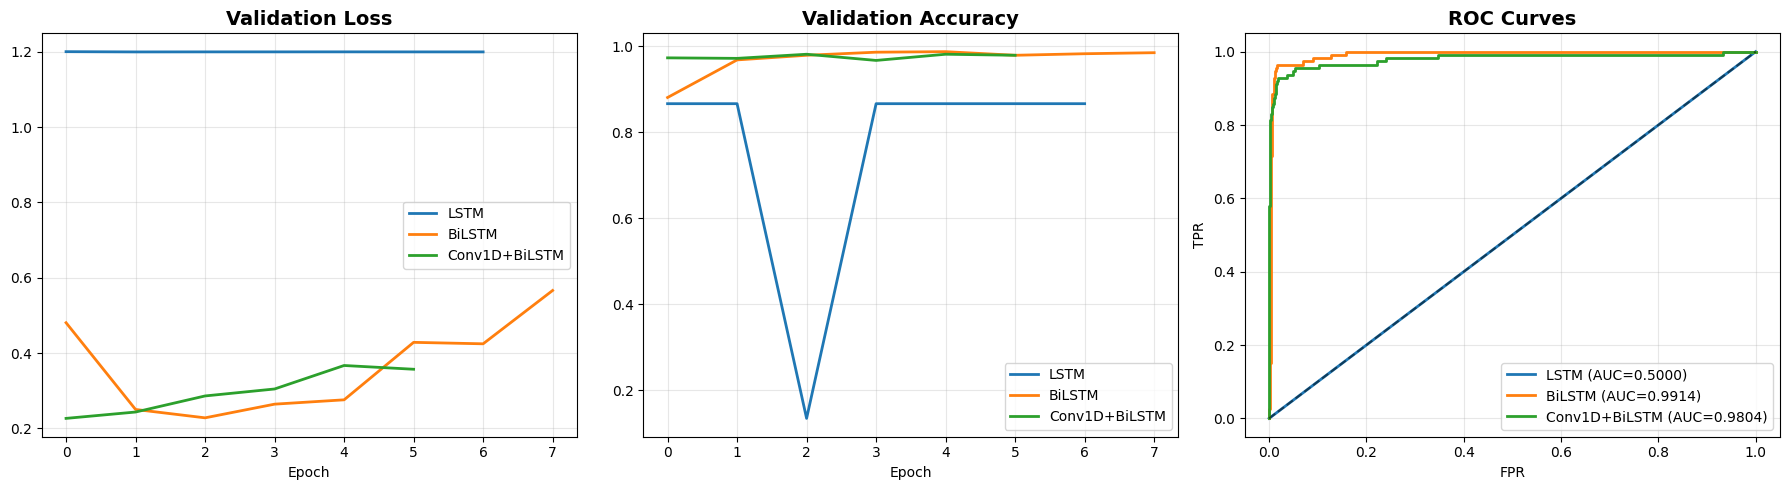

In [17]:
# Results table
results_df = pd.DataFrame(all_results).sort_values('f1', ascending=False).reset_index(drop=True)
print("\nMODEL COMPARISON (sorted by F1-Score):\n")
print(results_df.to_string(index=False))

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, hist in all_histories.items():
    axes[0].plot(hist['val_loss'], label=name, linewidth=2)
axes[0].set_title('Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for name, hist in all_histories.items():
    axes[1].plot(hist['val_acc'], label=name, linewidth=2)
axes[1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for name, (_, proba) in all_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[2].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.4f})')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[2].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

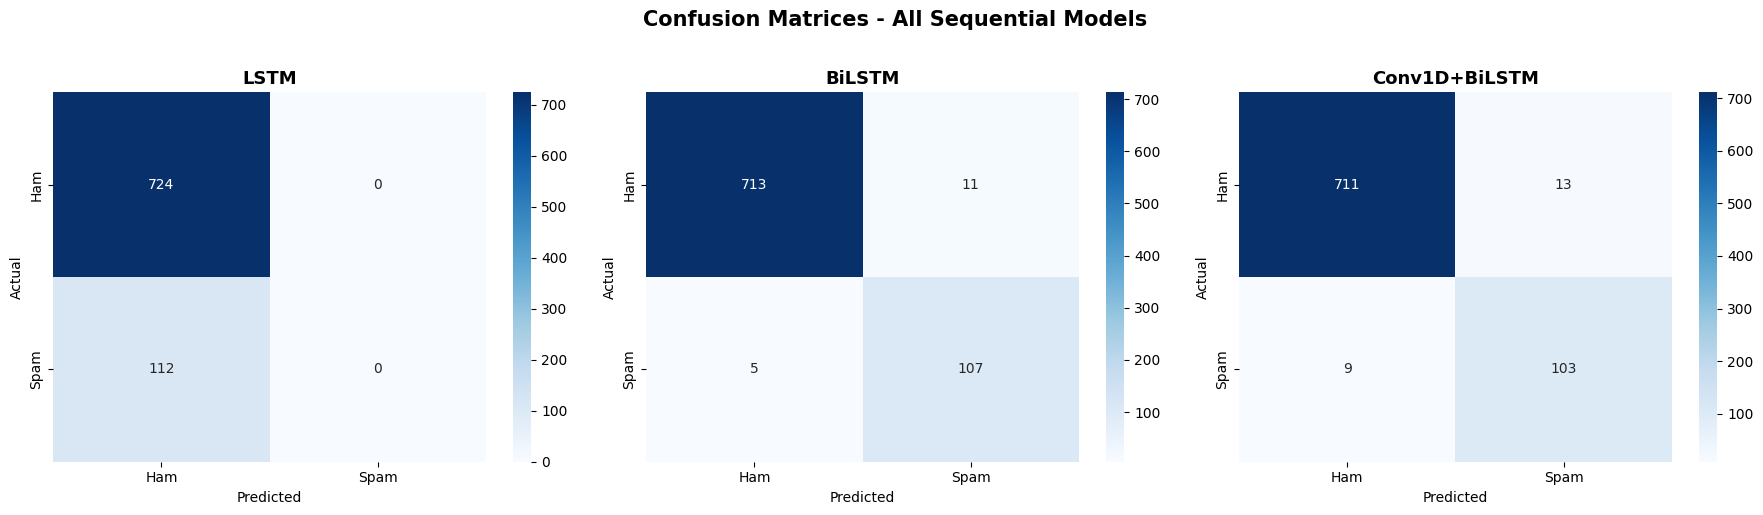

In [18]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (pred, _)) in zip(axes, all_predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - All Sequential Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **4. Test Best Sequential Model**

In [20]:
best = results_df.iloc[0]
print(f"\nBest Sequential Model: {best['name']}")
print(f"Accuracy: {best['accuracy']:.4f} | F1: {best['f1']:.4f} | AUC: {best['auc']:.4f}")

best_model_map = {'Simple LSTM': model_lstm, 'BiLSTM': model_bilstm, 'Conv1D+BiLSTM': model_conv}
best_model = best_model_map[best['name']]

@torch.no_grad()
def predict_spam(message, model=best_model):
    model.eval()
    cleaned = clean_text(message)
    encoded = torch.LongTensor([vocab.encode(cleaned, MAX_SEQ_LENGTH)]).to(device)
    logit = model(encoded)
    proba = torch.sigmoid(logit).item()
    label = "SPAM" if proba >= 0.5 else "HAM"
    return f"{label} ({max(proba, 1-proba):.1%})"

test_messages = [
    "Hey, are we still meeting for lunch tomorrow?",
    "CONGRATULATIONS! You've won a £1000 prize! Call 08001234567 NOW to claim!",
    "Can you pick up some milk on your way home?",
    "FREE entry to win £10000! Text WIN to 87121. T&Cs apply.",
    "I'll be there in 5 minutes, wait for me",
    "Urgent! Your account has been compromised. Click here to verify: http://spam.com"
]

print("\nPredictions:\n")
for msg in test_messages:
    print(f"{predict_spam(msg)}")
    print(f"=> \"{msg[:70]}...\"\n")


Best Sequential Model: BiLSTM
Accuracy: 0.9809 | F1: 0.9304 | AUC: 0.9914

Predictions:

HAM (99.7%)
=> "Hey, are we still meeting for lunch tomorrow?..."

SPAM (99.0%)
=> "CONGRATULATIONS! You've won a £1000 prize! Call 08001234567 NOW to cla..."

HAM (99.7%)
=> "Can you pick up some milk on your way home?..."

SPAM (99.4%)
=> "FREE entry to win £10000! Text WIN to 87121. T&Cs apply...."

HAM (99.7%)
=> "I'll be there in 5 minutes, wait for me..."

SPAM (93.3%)
=> "Urgent! Your account has been compromised. Click here to verify: http:..."



### **Summary**
- **Simple LSTM**
  - Expected Accuracy: ~96-97%
  - Expected F1: ~90-93%
  - Parameters: ~1.4M
- **BiLSTM**
  - Expected Accuracy: ~97-98%
  - Expected F1: ~92-95%
  - Parameters: ~2M
- **Conv1D + BiLSTM**
  - Expected Accuracy: ~97-98%
  - Expected F1: ~93-96%
  - Parameters: ~2.1M

#### **Key Takeaways:**
1. Sequential models improve over the Dense baseline, especially on **recall for spam**
2. **BiLSTM** captures bidirectional context effectively
3. **Conv1D + BiLSTM** hybrid combines local patterns with sequential context
4. Still limited by the small training set - **transfer learning** should unlock the best performance
